Continuing Playing with pandas, matplotlib and collab
by Analysing the Popularity of Different Programming Languages over Time

In [3]:
# Read the csv file with pandas, column should be 'DATE', 'TAG', 'POSTS'
# Setting the header row to 0 allows us to skip the first row, which was the old column names
import pandas as pd
df = pd.read_csv('/content/QueryResults.csv', names=['DATE', 'TAG', 'POSTS'], header=0)


## Data Exploration

In [4]:
# Show the first 5 rows
df.head()

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,javascript,162
3,2008-08-01 00:00:00,c,85
4,2008-08-01 00:00:00,python,124


In [5]:
# show the last 5 rows
df.tail()

,DATE,TAG,POSTS
1986,2020-07-01 00:00:00,r,5694
1987,2020-07-01 00:00:00,go,743
1988,2020-07-01 00:00:00,ruby,775
1989,2020-07-01 00:00:00,perl,182
1990,2020-07-01 00:00:00,swift,3607


In [6]:
# How many rows and columns?
df.shape

(1991, 3)

In [7]:
# Let's see which Tags have the most posts
df[['TAG', 'POSTS']].groupby('TAG').sum().sort_values('POSTS', ascending=False).head()

,POSTS
TAG,
javascript,2056510
java,1696403
python,1496210
c#,1423530
php,1361988


## Data Cleaning: Working with Time Stamps

In [8]:
# Let's look at the date column
df['DATE'].head()

,DATE
0,2008-07-01 00:00:00
1,2008-08-01 00:00:00
2,2008-08-01 00:00:00
3,2008-08-01 00:00:00
4,2008-08-01 00:00:00


In [9]:
# Let's also look at it's data type
type(df['DATE'][1])

str

In [10]:
# We can see that we are not dealing with a date object, but rather with a string.
# we also see the unnecessary 00:00:00
# let's convert it to datetime
df['DATE'] = pd.to_datetime(df['DATE'])
df['DATE'].head()

,DATE
0,2008-07-01
1,2008-08-01
2,2008-08-01
3,2008-08-01
4,2008-08-01


In [14]:
# Sometimes you want to convert your DataFrame so that each category has its own column.
# for that we can use the .pivot() method
reshaped_df = df.pivot(index='DATE', columns='TAG', values='POSTS')
reshaped_df.head()


TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,85.0,511.0,164.0,14.0,NaN,222.0,162.0,28.0,161.0,124.0,NaN,73.0,NaN
2008-09-01,28.0,321.0,1649.0,755.0,105.0,NaN,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,NaN
2008-10-01,15.0,303.0,1989.0,811.0,112.0,NaN,1153.0,725.0,127.0,617.0,510.0,NaN,249.0,NaN
2008-11-01,17.0,259.0,1730.0,735.0,141.0,NaN,958.0,579.0,97.0,504.0,452.0,1.0,160.0,NaN


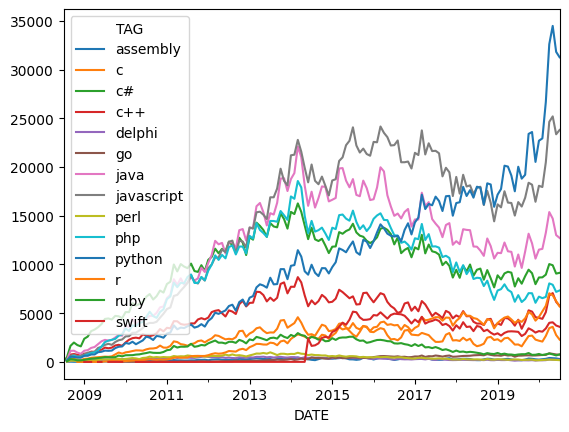

In [15]:
# Now we can plot it
import matplotlib.pyplot as plt
reshaped_df.plot()
plt.show()

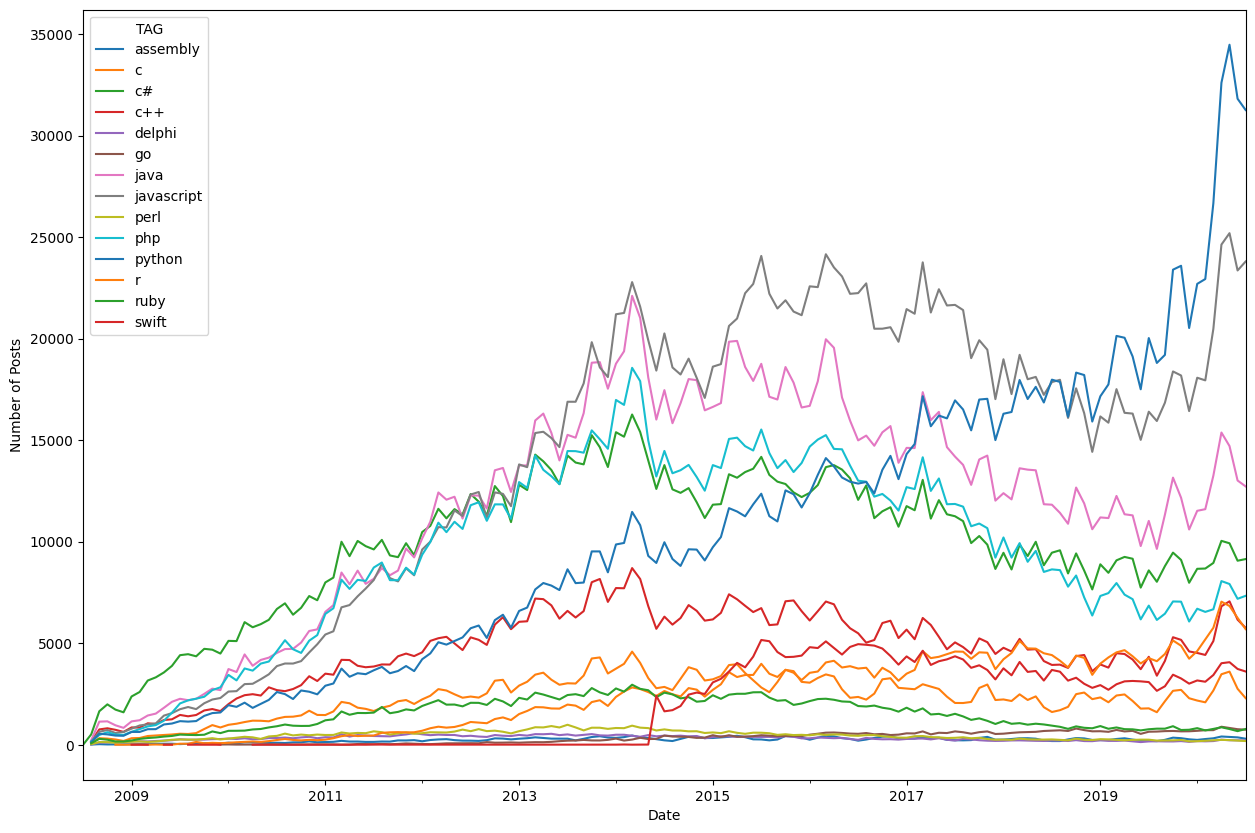

In [ ]:
# Styling the Chart
reshaped_df.plot(figsize=(15, 10))
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.show()

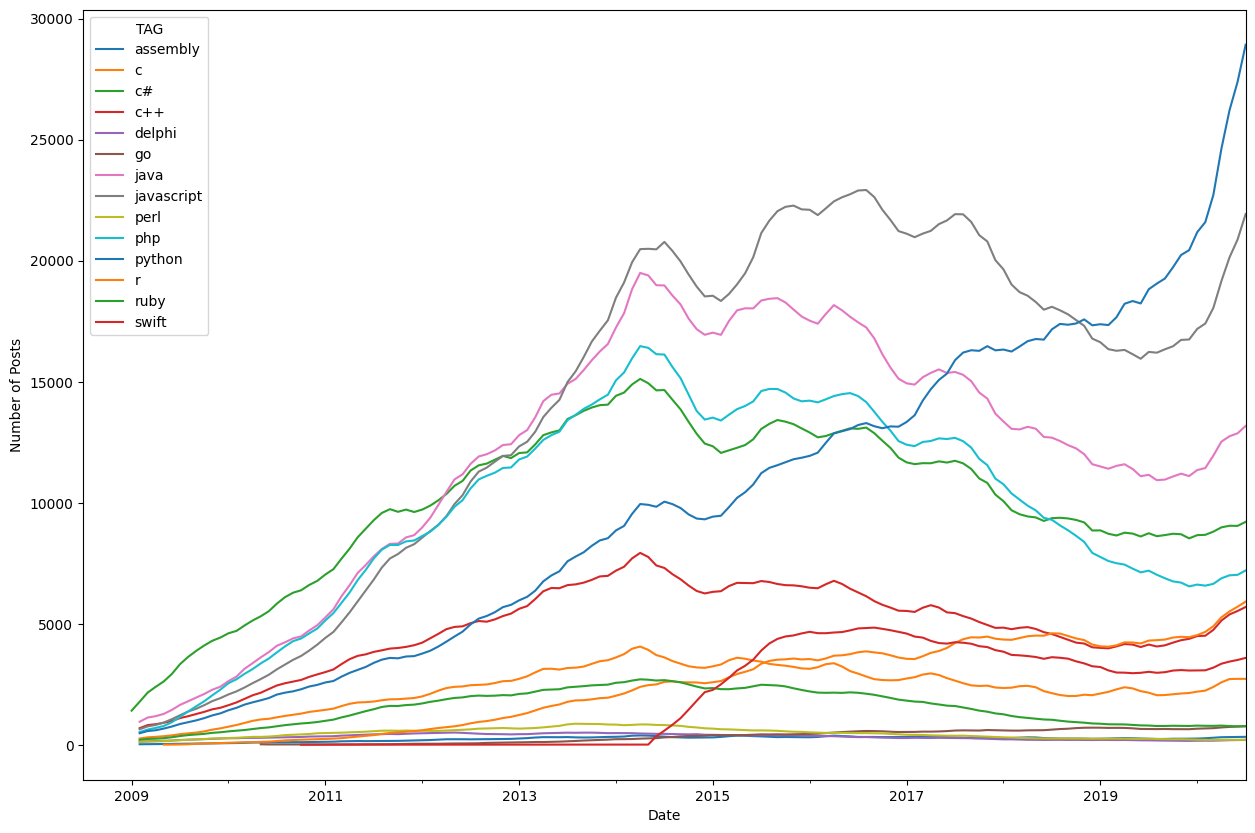

In [ ]:
# Creating a rolling average, to smooth the data and see the trend
reshaped_df.rolling(7).mean().plot(figsize=(15, 10))
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.show()